# Experiment: Fraud-type filtering — does dropping non-fraud transaction types help?

**Research question:** PaySim fraud occurs only in TRANSFER and CASH_OUT transactions.
Should we drop CASH_IN, DEBIT, and PAYMENT rows (which never contain fraud) before training?

**Hypothesis:** Keeping all transaction types is the correct design choice because:
- The classifier must generalise to all incoming transactions in production.
- Dropping non-fraud types artificially inflates the fraud rate, changing the learning problem.
- We expect comparable or worse performance on the filtered data.

This notebook trains the best-performing model (XGB with feature engineering + SMOTE, 10:1 weighted cost)
on both the **full** dataset and a **type-filtered** dataset, then compares them head-to-head.


In [1]:
from pathlib import Path
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import ConfusionMatrixDisplay

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from cost_config import FN_WEIGHT, FP_WEIGHT, COST_LABEL, COST_FORMULA

from tabular_xgboost_utils import (
    prepare_dataframes,
    build_preprocessor,
    compute_scale_pos_weight,
    build_xgb_pipeline,
    fit_model,
    evaluate_model,
    search_thresholds,
    compute_cost_table,
    evaluate_with_threshold,
    compute_expected_cost_from_cm,
    save_experiment_outputs,
)

processed_dir = project_root / "data" / "processed"
results_root  = project_root / "results" / "type_filter_experiment"
results_root.mkdir(parents=True, exist_ok=True)

SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)

print("Project root :", project_root)
print("Results dir  :", results_root)
print(f"Cost config  : FN_WEIGHT={FN_WEIGHT}, FP_WEIGHT={FP_WEIGHT}  ({COST_FORMULA})")


Project root : c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
Results dir  : c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\type_filter_experiment
Cost config  : FN_WEIGHT=10, FP_WEIGHT=1  (cost = FN x 10 + FP x 1)


## 1. Load data and inspect transaction types

In [2]:
paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val   = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test  = pd.read_csv(processed_dir / "paysim_test.csv")

print("Train shape:", paysim_train.shape)
print("Val   shape:", paysim_val.shape)
print("Test  shape:", paysim_test.shape)


Train shape: (4453834, 12)
Val   shape: (636262, 12)
Test  shape: (1272524, 12)


### 1.1 Which transaction types contain fraud?

We first verify which `type` values ever carry a fraud label.
This motivates the filtering experiment.

In [3]:
def fraud_by_type_summary(df, split_name="train"):
    """Return per-type row counts, fraud counts, and fraud rates."""
    summary = (
        df.groupby("type")["isFraud"]
        .agg(total="count", fraud_count="sum")
        .assign(fraud_rate_pct=lambda x: (x["fraud_count"] / x["total"] * 100).round(3))
        .sort_values("fraud_count", ascending=False)
    )
    print(f"\n=== Fraud distribution by transaction type — {split_name} ===")
    print(summary.to_string())
    return summary

type_summary_train = fraud_by_type_summary(paysim_train, "train")
type_summary_val   = fraud_by_type_summary(paysim_val,   "val")
type_summary_test  = fraud_by_type_summary(paysim_test,  "test")



=== Fraud distribution by transaction type — train ===
        total  fraud_count  fraud_rate_pct
type                                      
1     1566250         2883           0.184
4      373140         2866           0.768
0      979357            0           0.000
2       29102            0           0.000
3     1505985            0           0.000

=== Fraud distribution by transaction type — val ===
       total  fraud_count  fraud_rate_pct
type                                     
1     224057          435           0.194
4      53242          386           0.725
0     139669            0           0.000
2       4045            0           0.000
3     215249            0           0.000

=== Fraud distribution by transaction type — test ===
       total  fraud_count  fraud_rate_pct
type                                     
4     106527          845           0.793
1     447193          798           0.178
0     280258            0           0.000
2       8285            0     

In [4]:
# Identify types that NEVER carry fraud in the training set
fraud_types    = type_summary_train[type_summary_train["fraud_count"] > 0].index.tolist()
no_fraud_types = type_summary_train[type_summary_train["fraud_count"] == 0].index.tolist()

print("Transaction types WITH fraud cases    :", [str(t) for t in fraud_types])
print("Transaction types WITHOUT fraud cases :", [str(t) for t in no_fraud_types])
print()
print(f"Rows in train that belong to fraud types  : "
      f"{paysim_train['type'].isin(fraud_types).sum():,} "
      f"({paysim_train['type'].isin(fraud_types).mean()*100:.1f}%)")
print(f"Rows in train dropped by filtering        : "
      f"{paysim_train['type'].isin(no_fraud_types).sum():,} "
      f"({paysim_train['type'].isin(no_fraud_types).mean()*100:.1f}%)")


Transaction types WITH fraud cases    : ['1', '4']
Transaction types WITHOUT fraud cases : ['0', '2', '3']

Rows in train that belong to fraud types  : 1,939,390 (43.5%)
Rows in train dropped by filtering        : 2,514,444 (56.5%)


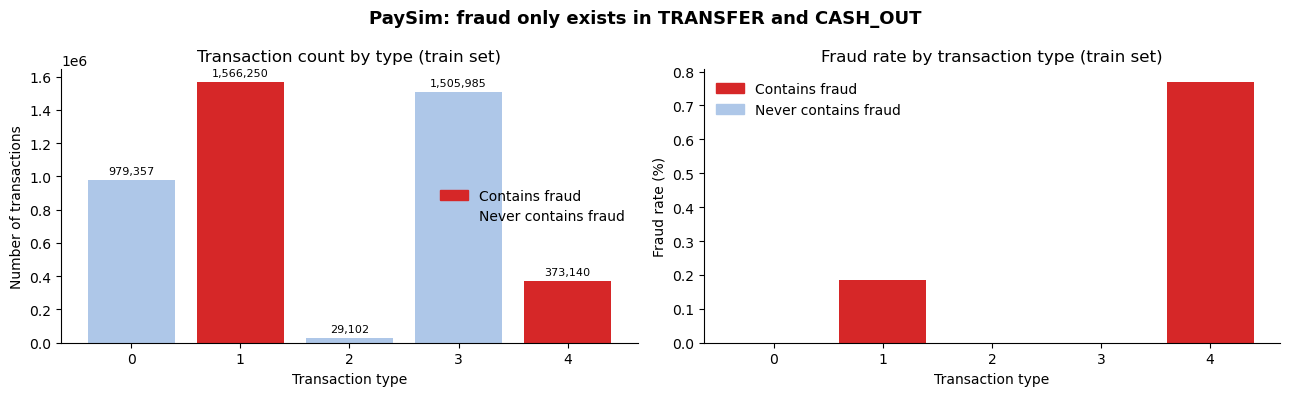

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: row counts
ax = axes[0]
colors = ["#d62728" if t in fraud_types else "#aec7e8" for t in type_summary_train.index]
bars = ax.bar(type_summary_train.index, type_summary_train["total"], color=colors)
ax.bar_label(bars, labels=[f"{v:,}" for v in type_summary_train["total"]], padding=3, fontsize=8)
ax.set_title("Transaction count by type (train set)", fontsize=12)
ax.set_ylabel("Number of transactions")
ax.set_xlabel("Transaction type")
ax.spines[["top","right"]].set_visible(False)

# Fake legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#d62728", label="Contains fraud"),
    Patch(color="#aec7e8", label="Never contains fraud"),
], frameon=False)

# Panel 2: fraud rate
ax = axes[1]
ax.bar(type_summary_train.index, type_summary_train["fraud_rate_pct"], color=colors)
ax.set_title("Fraud rate by transaction type (train set)", fontsize=12)
ax.set_ylabel("Fraud rate (%)")
ax.set_xlabel("Transaction type")
ax.spines[["top","right"]].set_visible(False)
ax.legend(handles=[
    Patch(color="#d62728", label="Contains fraud"),
    Patch(color="#aec7e8", label="Never contains fraud"),
], frameon=False)

plt.suptitle("PaySim: fraud only exists in TRANSFER and CASH_OUT", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(results_root / "type_fraud_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Finding:** Fraud exists only in `TRANSFER` and `CASH_OUT`. 
The remaining types (`CASH_IN`, `DEBIT`, `PAYMENT`) contribute zero fraud cases 
but make up a substantial share of transactions.

The filtering experiment drops these zero-fraud types from all three splits 
and retrains the best model (XGB + FE + SMOTE) to measure the impact.


## 2. Class imbalance before and after filtering

In [6]:
def imbalance_stats(df, label):
    """Print imbalance summary for a dataframe."""
    n_total  = len(df)
    n_fraud  = df["isFraud"].sum()
    n_legit  = n_total - n_fraud
    rate     = n_fraud / n_total * 100
    ratio    = n_legit / n_fraud if n_fraud > 0 else float("inf")
    print(f"{label:50s}  total={n_total:>10,}  fraud={n_fraud:>7,}  "
          f"fraud_rate={rate:5.2f}%  legit:fraud={ratio:.0f}:1")

print("Class imbalance comparison (training split)")
print("-" * 110)
imbalance_stats(paysim_train, "Full dataset (all types)")

train_filtered = paysim_train[paysim_train["type"].isin(fraud_types)].copy()
val_filtered   = paysim_val  [paysim_val  ["type"].isin(fraud_types)].copy()
test_filtered  = paysim_test [paysim_test ["type"].isin(fraud_types)].copy()

fraud_types_label = ", ".join(str(t) for t in fraud_types)
imbalance_stats(train_filtered, f"Filtered dataset ({fraud_types_label} only)")
print()
print(f"Rows removed from train : {len(paysim_train) - len(train_filtered):,}")
print(f"Rows removed from val   : {len(paysim_val)   - len(val_filtered):,}")
print(f"Rows removed from test  : {len(paysim_test)  - len(test_filtered):,}")


Class imbalance comparison (training split)
--------------------------------------------------------------------------------------------------------------
Full dataset (all types)                            total= 4,453,834  fraud=  5,749  fraud_rate= 0.13%  legit:fraud=774:1
Filtered dataset (1, 4 only)                        total= 1,939,390  fraud=  5,749  fraud_rate= 0.30%  legit:fraud=336:1

Rows removed from train : 2,514,444
Rows removed from val   : 358,963
Rows removed from test  : 718,804


**Key insight:** Dropping zero-fraud types substantially increases the apparent fraud rate.
This changes the learning problem: the model is no longer trained on the realistic 
production distribution where most incoming transactions are non-fraud types.

A model trained on the filtered data would need a different decision threshold 
and may not generalise to the full production stream.


## 3. Reference model — XGB FE-SMOTE on full data

We load (or retrain) the best model from notebook 12 to use as the reference baseline.
This is XGB with feature engineering + SMOTE, tuned with 10:1 weighted cost.


In [7]:
# ── Prepare full-dataset feature matrices ─────────────────────────────────
data_full = prepare_dataframes(paysim_train, paysim_val, paysim_test,
                               use_feature_engineering=True)

X_train_full = data_full["X_train"]; y_train_full = data_full["y_train"]
X_val_full   = data_full["X_val"];   y_val_full   = data_full["y_val"]
X_test_full  = data_full["X_test"];  y_test_full  = data_full["y_test"]
num_feats_full = data_full["numeric_features"]
cat_feats_full = data_full["categorical_features"]
spw_full       = compute_scale_pos_weight(y_train_full)

assert "isFlaggedFraud" in X_train_full.columns, "isFlaggedFraud missing!"
print("Features:", data_full["feature_cols"])
print(f"Train shape: {X_train_full.shape}  |  fraud: {y_train_full.sum():,}")


Features: ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'balance_delta_orig', 'balance_delta_dest', 'amount_to_balance_ratio', 'orig_balance_zeroed']
Train shape: (4453834, 12)  |  fraud: 5,749


In [8]:
# ── Load or train full-data model ─────────────────────────────────────────
ref_model_path = project_root / "results" / "xgb_fe_smote" / "fe_smote_model.joblib"
FORCE_RETRAIN  = False

if ref_model_path.exists() and not FORCE_RETRAIN:
    print("Loading saved reference model from nb12...")
    model_full = joblib.load(ref_model_path)
    print("Loaded:", ref_model_path)
else:
    print("Training reference model (XGB FE-SMOTE)...")
    preprocessor = build_preprocessor(num_feats_full, cat_feats_full)
    model_full = build_xgb_pipeline(
        preprocessor=preprocessor,
        imbalance_method="smote",
        scale_pos_weight=spw_full,
        smote_sampling_strategy=0.1,
    )
    model_full = fit_model(model_full, X_train_full, y_train_full,
                           eval_set=(X_val_full, y_val_full))
    joblib.dump(model_full, results_root / "reference_full_model.joblib")
    print("Trained and saved.")


Loading saved reference model from nb12...
Loaded: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\xgb_fe_smote\fe_smote_model.joblib


In [9]:
# ── Threshold tuning on full-data validation set ───────────────────────────
threshold_results_full = search_thresholds(model_full, X_val_full, y_val_full)
cost_df_full           = compute_cost_table(threshold_results_full, y_val_full)
best_threshold_full    = float(cost_df_full.iloc[0]["threshold"])

print(f"Best validation threshold (full data): {best_threshold_full}")
print(cost_df_full.head(5).to_string(index=False))


Best validation threshold (full data): 0.9500000000000003
 threshold  tp  fp  fn     tn  precision  recall       f1  predicted_fraud  expected_cost
      0.95 821   0   0 635441   1.000000     1.0 1.000000              821              0
      0.85 821   1   0 635440   0.998783     1.0 0.999391              822              1
      0.80 821   1   0 635440   0.998783     1.0 0.999391              822              1
      0.75 821   1   0 635440   0.998783     1.0 0.999391              822              1
      0.90 821   1   0 635440   0.998783     1.0 0.999391              822              1


In [10]:
# ── Evaluate reference model on test set ──────────────────────────────────
val_metrics_full,  val_cm_full  = evaluate_model(model_full, X_val_full,  y_val_full,  "val_full")
test_metrics_full, test_cm_full = evaluate_model(model_full, X_test_full, y_test_full, "test_full")

tuned_metrics_full, tuned_cm_full = evaluate_with_threshold(
    model_full, X_test_full, y_test_full, best_threshold_full)
cost_full = compute_expected_cost_from_cm(tuned_cm_full)

tn, fp, fn, tp = tuned_cm_full.ravel()
print(f"\n=== Reference model (full data) — tuned threshold={best_threshold_full} ===")
print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"  Precision={tuned_metrics_full['precision']:.4f}  "
      f"Recall={tuned_metrics_full['recall']:.4f}  "
      f"F1={tuned_metrics_full['f1']:.4f}")
print(f"  Weighted cost (FN×{FN_WEIGHT} + FP×{FP_WEIGHT}) = {cost_full['expected_cost']:,}")



=== VAL_FULL ===
  accuracy: 0.999976
  precision: 0.982057
  recall: 1.000000
  f1: 0.990947
  roc_auc: 1.000000
  pr_auc: 1.000000

Confusion matrix:
 [[635426     15]
 [     0    821]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    635441
           1     0.9821    1.0000    0.9909       821

    accuracy                         1.0000    636262
   macro avg     0.9910    1.0000    0.9955    636262
weighted avg     1.0000    1.0000    1.0000    636262


=== TEST_FULL ===
  accuracy: 0.999976
  precision: 0.983794
  recall: 0.997565
  f1: 0.990632
  roc_auc: 0.999756
  pr_auc: 0.998648

Confusion matrix:
 [[1270854      27]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9838    0.9976    0.9906      1643

    accuracy                         1.0000   1272524
   macro avg     0.9919 

## 4. Filtered model — XGB FE-SMOTE on TRANSFER + CASH_OUT only

Same model architecture and hyperparameters. 
The only change is the training (and evaluation) data.

**Important:** The test set is also filtered to the same types so evaluation is 
done on the same decision space — comparing like for like on the fraud-type rows.
We then also evaluate the filtered model on the **full** test set to show 
what happens in production when it encounters all transaction types.


In [11]:
# ── Prepare filtered feature matrices ─────────────────────────────────────
data_filt = prepare_dataframes(train_filtered, val_filtered, test_filtered,
                               use_feature_engineering=True)

X_train_filt = data_filt["X_train"]; y_train_filt = data_filt["y_train"]
X_val_filt   = data_filt["X_val"];   y_val_filt   = data_filt["y_val"]
X_test_filt  = data_filt["X_test"];  y_test_filt  = data_filt["y_test"]
num_feats_filt = data_filt["numeric_features"]
cat_feats_filt = data_filt["categorical_features"]
spw_filt       = compute_scale_pos_weight(y_train_filt)

assert "isFlaggedFraud" in X_train_filt.columns, "isFlaggedFraud missing!"
print("Features:", data_filt["feature_cols"])
print(f"Train shape: {X_train_filt.shape}  |  fraud: {y_train_filt.sum():,}")
print(f"Val   shape: {X_val_filt.shape}    |  fraud: {y_val_filt.sum():,}")
print(f"Test  shape: {X_test_filt.shape}   |  fraud: {y_test_filt.sum():,}")
print(f"\nscale_pos_weight (filtered): {spw_filt:.4f}  "
      f"(vs full: {spw_full:.4f}  — lower because fraud rate is higher after filtering)")


Features: ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'balance_delta_orig', 'balance_delta_dest', 'amount_to_balance_ratio', 'orig_balance_zeroed']
Train shape: (1939390, 12)  |  fraud: 5,749
Val   shape: (277299, 12)    |  fraud: 821
Test  shape: (553720, 12)   |  fraud: 1,643

scale_pos_weight (filtered): 336.3439  (vs full: 773.7146  — lower because fraud rate is higher after filtering)


In [12]:
# ── Train filtered model ──────────────────────────────────────────────────
filt_model_path = results_root / "filtered_model.joblib"
FORCE_RETRAIN   = False

if filt_model_path.exists() and not FORCE_RETRAIN:
    print("Loading saved filtered model...")
    model_filt = joblib.load(filt_model_path)
    print("Loaded.")
else:
    print("Training filtered model (XGB FE-SMOTE on TRANSFER+CASH_OUT only)...")
    preprocessor = build_preprocessor(num_feats_filt, cat_feats_filt)
    model_filt = build_xgb_pipeline(
        preprocessor=preprocessor,
        imbalance_method="smote",
        scale_pos_weight=spw_filt,
        smote_sampling_strategy=0.1,
    )
    model_filt = fit_model(model_filt, X_train_filt, y_train_filt,
                           eval_set=(X_val_filt, y_val_filt))
    joblib.dump(model_filt, filt_model_path)
    print("Trained and saved:", filt_model_path)


Training filtered model (XGB FE-SMOTE on TRANSFER+CASH_OUT only)...
  Early stopping: used 300 / 300 trees.
Trained and saved: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\type_filter_experiment\filtered_model.joblib


In [13]:
# ── Threshold tuning on filtered validation set ────────────────────────────
threshold_results_filt = search_thresholds(model_filt, X_val_filt, y_val_filt)
cost_df_filt           = compute_cost_table(threshold_results_filt, y_val_filt)
best_threshold_filt    = float(cost_df_filt.iloc[0]["threshold"])

print(f"Best validation threshold (filtered): {best_threshold_filt}")
print(cost_df_filt.head(5).to_string(index=False))


Best validation threshold (filtered): 0.9500000000000003
 threshold  tp  fp  fn     tn  precision  recall       f1  predicted_fraud  expected_cost
      0.95 821   0   0 276478   1.000000     1.0 1.000000              821              0
      0.70 821   1   0 276477   0.998783     1.0 0.999391              822              1
      0.80 821   1   0 276477   0.998783     1.0 0.999391              822              1
      0.75 821   1   0 276477   0.998783     1.0 0.999391              822              1
      0.65 821   1   0 276477   0.998783     1.0 0.999391              822              1


In [14]:
# ── Evaluate filtered model on filtered test set (like-for-like) ──────────
val_metrics_filt,  val_cm_filt  = evaluate_model(model_filt, X_val_filt,  y_val_filt,  "val_filt")
test_metrics_filt, test_cm_filt = evaluate_model(model_filt, X_test_filt, y_test_filt, "test_filt")

tuned_metrics_filt, tuned_cm_filt = evaluate_with_threshold(
    model_filt, X_test_filt, y_test_filt, best_threshold_filt)
cost_filt = compute_expected_cost_from_cm(tuned_cm_filt)

tn, fp, fn, tp = tuned_cm_filt.ravel()
print(f"\n=== Filtered model (TRANSFER+CASH_OUT test set) — threshold={best_threshold_filt} ===")
print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"  Precision={tuned_metrics_filt['precision']:.4f}  "
      f"Recall={tuned_metrics_filt['recall']:.4f}  "
      f"F1={tuned_metrics_filt['f1']:.4f}")
print(f"  Weighted cost (FN×{FN_WEIGHT} + FP×{FP_WEIGHT}) = {cost_filt['expected_cost']:,}")



=== VAL_FILT ===
  accuracy: 0.999978
  precision: 0.992745
  recall: 1.000000
  f1: 0.996359
  roc_auc: 1.000000
  pr_auc: 1.000000

Confusion matrix:
 [[276472      6]
 [     0    821]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    276478
           1     0.9927    1.0000    0.9964       821

    accuracy                         1.0000    277299
   macro avg     0.9964    1.0000    0.9982    277299
weighted avg     1.0000    1.0000    1.0000    277299


=== TEST_FILT ===
  accuracy: 0.999964
  precision: 0.990332
  recall: 0.997565
  f1: 0.993936
  roc_auc: 0.999355
  pr_auc: 0.998623

Confusion matrix:
 [[552061     16]
 [     4   1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    552077
           1     0.9903    0.9976    0.9939      1643

    accuracy                         1.0000    553720
   macro avg     0.9952    0

### 4.1 Filtered model evaluated on the full test set

In production, the model receives **all** transaction types.
We apply the filtered model to the full test set to simulate this.

For rows with non-fraud types, the true label is always 0.
The filtered model was never shown these rows, so its calibration may be off.


In [15]:
# Align the full test feature set to the filtered model's feature space
# (features are the same since prepare_dataframes produces identical columns)
tuned_metrics_filt_on_full, tuned_cm_filt_on_full = evaluate_with_threshold(
    model_filt, X_test_full, y_test_full, best_threshold_filt)
cost_filt_on_full = compute_expected_cost_from_cm(tuned_cm_filt_on_full)

tn, fp, fn, tp = tuned_cm_filt_on_full.ravel()
print(f"=== Filtered model evaluated on FULL test set — threshold={best_threshold_filt} ===")
print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"  Precision={tuned_metrics_filt_on_full['precision']:.4f}  "
      f"Recall={tuned_metrics_filt_on_full['recall']:.4f}  "
      f"F1={tuned_metrics_filt_on_full['f1']:.4f}")
print(f"  Weighted cost (FN×{FN_WEIGHT} + FP×{FP_WEIGHT}) = {cost_filt_on_full['expected_cost']:,}")
print()
print("Note: additional FP here come from non-fraud types being incorrectly flagged.")



Tuned threshold : 0.9500000000000003
  Precision     : 0.993333
  Recall        : 0.997565
  F1            : 0.995445

Confusion matrix:
 [[1270870      11]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9933    0.9976    0.9954      1643

    accuracy                         1.0000   1272524
   macro avg     0.9967    0.9988    0.9977   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

=== Filtered model evaluated on FULL test set — threshold=0.9500000000000003 ===
  TN=1,270,870  FP=11  FN=4  TP=1,639
  Precision=0.9933  Recall=0.9976  F1=0.9954
  Weighted cost (FN×10 + FP×1) = 51

Note: additional FP here come from non-fraud types being incorrectly flagged.


## 5. Head-to-head comparison

In [16]:
def cm_to_dict(model_name, tuned_metrics, tuned_cm, cost_dict, threshold, test_label):
    tn, fp, fn, tp = np.asarray(tuned_cm).ravel()
    return {
        "model"          : model_name,
        "test_set"       : test_label,
        "threshold"      : threshold,
        "TP"             : int(tp),
        "FN"             : int(fn),
        "FP"             : int(fp),
        "TN"             : int(tn),
        "precision"      : tuned_metrics["precision"],
        "recall"         : tuned_metrics["recall"],
        "f1"             : tuned_metrics["f1"],
        "weighted_cost"  : cost_dict["expected_cost"],
    }

comparison = pd.DataFrame([
    cm_to_dict("XGB FE-SMOTE  (full data)",
               tuned_metrics_full,        tuned_cm_full,
               cost_full,                 best_threshold_full,  "Full test set"),
    cm_to_dict("XGB FE-SMOTE  (filtered)",
               tuned_metrics_filt,        tuned_cm_filt,
               cost_filt,                 best_threshold_filt,  "Filtered test set"),
    cm_to_dict("XGB FE-SMOTE  (filtered, on full test)",
               tuned_metrics_filt_on_full, tuned_cm_filt_on_full,
               cost_filt_on_full,          best_threshold_filt,  "Full test set"),
])

display_cols = ["model","test_set","threshold","TP","FN","FP","TN",
                "precision","recall","f1","weighted_cost"]
print(comparison[display_cols].to_string(index=False))
comparison.to_csv(results_root / "type_filter_comparison.csv", index=False)
print("\nSaved to:", results_root / "type_filter_comparison.csv")


                                 model          test_set  threshold   TP  FN  FP      TN  precision   recall       f1  weighted_cost
             XGB FE-SMOTE  (full data)     Full test set       0.95 1639   4   0 1270881   1.000000 0.997565 0.998781             40
              XGB FE-SMOTE  (filtered) Filtered test set       0.95 1639   4   0  552077   1.000000 0.997565 0.998781             40
XGB FE-SMOTE  (filtered, on full test)     Full test set       0.95 1639   4  11 1270870   0.993333 0.997565 0.995445             51

Saved to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\type_filter_experiment\type_filter_comparison.csv


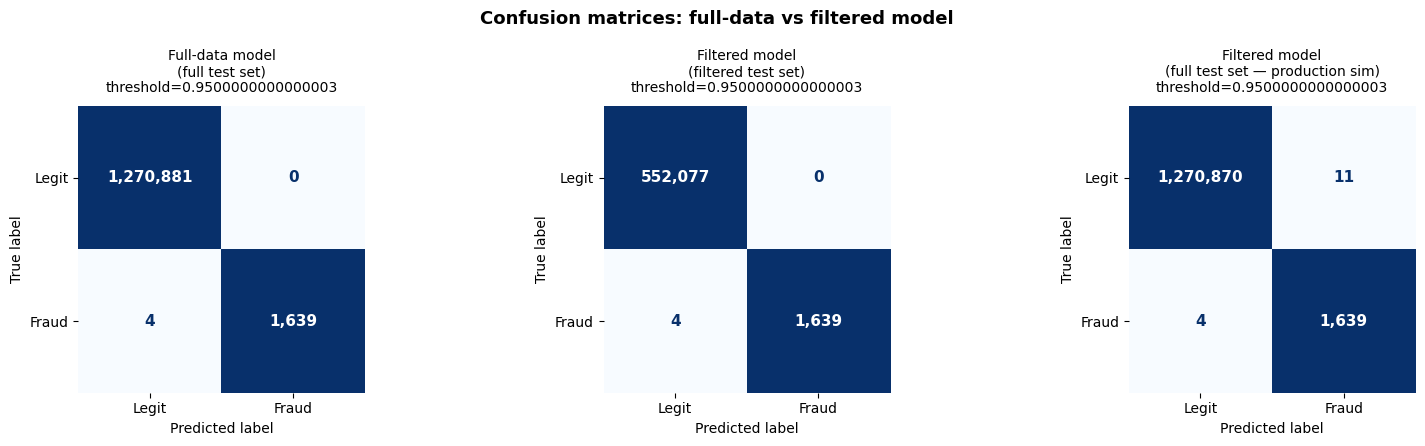

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

panels = [
    (tuned_cm_full,           f"Full-data model\n(full test set)\nthreshold={best_threshold_full}"),
    (tuned_cm_filt,           f"Filtered model\n(filtered test set)\nthreshold={best_threshold_filt}"),
    (tuned_cm_filt_on_full,   f"Filtered model\n(full test set — production sim)\nthreshold={best_threshold_filt}"),
]

for ax, (cm, title) in zip(axes, panels):
    cm_arr  = np.asarray(cm).astype(int)
    cm_norm = cm_arr.astype(float)
    cm_norm[0] = cm_norm[0] / (cm_norm[0].sum() + 1e-9)
    cm_norm[1] = cm_norm[1] / (cm_norm[1].sum() + 1e-9)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Legit","Fraud"]); ax.set_yticklabels(["Legit","Fraud"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title(title, fontsize=10, pad=10)
    for i in range(2):
        for j in range(2):
            val  = cm_arr[i,j]
            rate = cm_norm[i,j]
            rgba = im.cmap(rate)
            lum  = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            tc   = "white" if lum < 0.45 else "#08306b"
            ax.text(j, i, f"{val:,}", ha="center", va="center",
                    fontsize=11, fontweight="bold", color=tc)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle("Confusion matrices: full-data vs filtered model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(results_root / "confusion_matrices_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


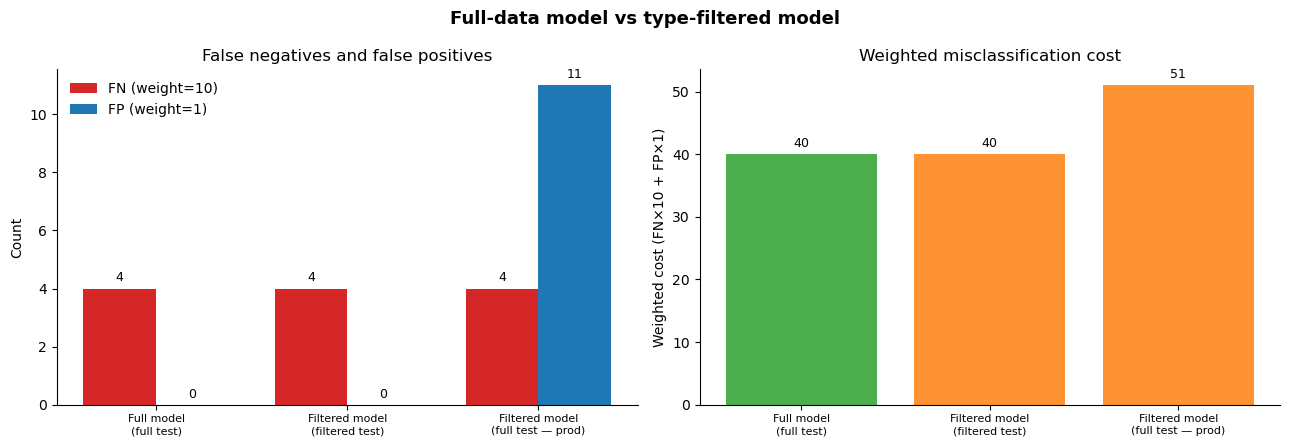

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

labels = ["Full model\n(full test)", "Filtered model\n(filtered test)", "Filtered model\n(full test — prod)"]
fn_vals   = comparison["FN"].tolist()
fp_vals   = comparison["FP"].tolist()
cost_vals = comparison["weighted_cost"].tolist()

# Panel 1: FN and FP side by side
ax = axes[0]
x = np.arange(3); w = 0.38
b1 = ax.bar(x - w/2, fn_vals, w, label=f"FN (weight={FN_WEIGHT})", color="#d62728")
b2 = ax.bar(x + w/2, fp_vals, w, label=f"FP (weight={FP_WEIGHT})", color="#1f77b4")
ax.bar_label(b1, padding=3, fontsize=9)
ax.bar_label(b2, padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Count"); ax.set_title("False negatives and false positives")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)

# Panel 2: weighted cost
ax = axes[1]
colors_c = ["#2ca02c", "#ff7f0e", "#ff7f0e"]
bars = ax.bar(labels, cost_vals, color=colors_c, alpha=0.85)
ax.bar_label(bars, labels=[f"{v:,}" for v in cost_vals], padding=3, fontsize=9)
ax.set_ylabel(f"Weighted cost (FN×{FN_WEIGHT} + FP×{FP_WEIGHT})")
ax.set_title("Weighted misclassification cost")
ax.tick_params(axis="x", labelsize=8)
ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Full-data model vs type-filtered model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(results_root / "fn_fp_cost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.1 Precision-Recall curves (validation set)

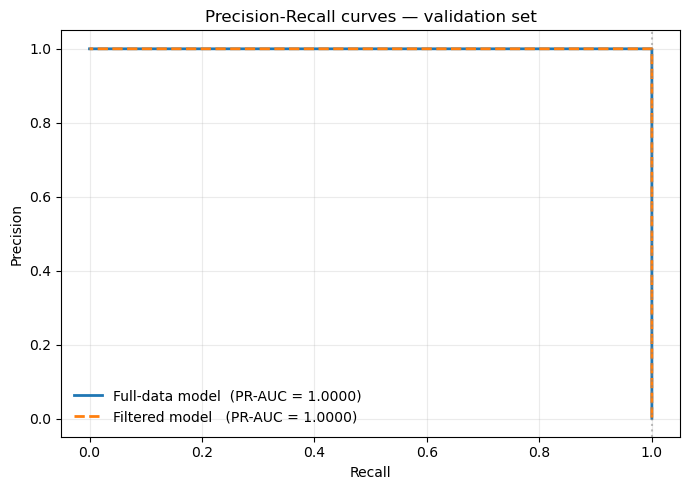

Full-data model PR-AUC : 1.0000
Filtered model  PR-AUC : 1.0000


In [19]:
from sklearn.metrics import precision_recall_curve, auc

scores_full = model_full.predict_proba(X_val_full)[:, 1]
scores_filt = model_filt.predict_proba(X_val_filt)[:, 1]

p_full, r_full, _ = precision_recall_curve(y_val_full, scores_full)
p_filt, r_filt, _ = precision_recall_curve(y_val_filt, scores_filt)

auc_full = auc(r_full, p_full)
auc_filt = auc(r_filt, p_filt)

plt.figure(figsize=(7, 5))
plt.plot(r_full, p_full, label=f"Full-data model  (PR-AUC = {auc_full:.4f})", linewidth=2)
plt.plot(r_filt, p_filt, label=f"Filtered model   (PR-AUC = {auc_filt:.4f})", linewidth=2, linestyle="--")
plt.axvline(x=1.0, linestyle=":", color="grey", alpha=0.5)
plt.title("Precision-Recall curves — validation set", fontsize=12)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend(frameon=False); plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(results_root / "pr_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Full-data model PR-AUC : {auc_full:.4f}")
print(f"Filtered model  PR-AUC : {auc_filt:.4f}")


### 5.2 Cost curve comparison — how threshold choice differs

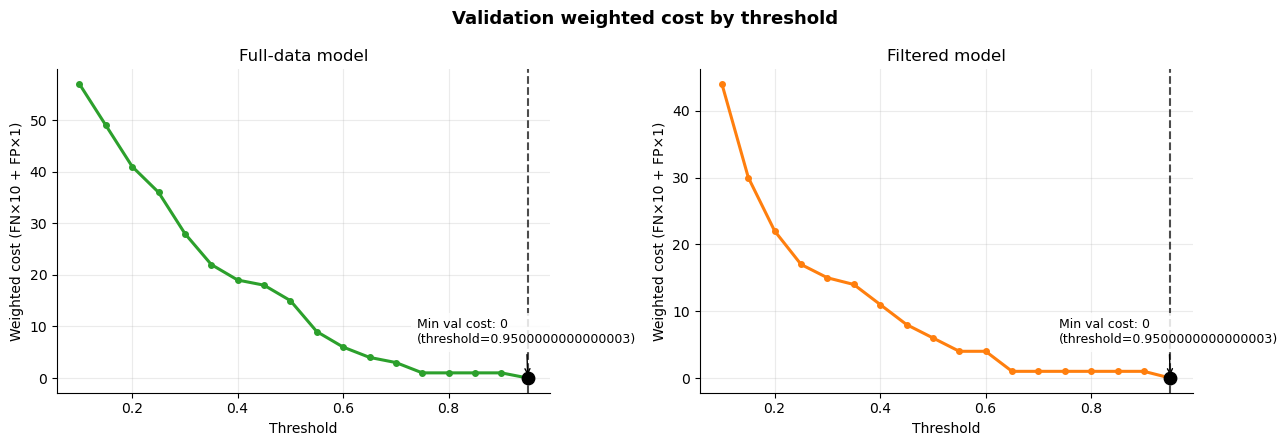

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (cost_df, thr, label, color) in zip(axes, [
    (cost_df_full, best_threshold_full, "Full-data model", "#2ca02c"),
    (cost_df_filt, best_threshold_filt, "Filtered model",  "#ff7f0e"),
]):
    df_s = cost_df.sort_values("threshold")
    best = cost_df.loc[cost_df["expected_cost"].idxmin()]
    ax.plot(df_s["threshold"], df_s["expected_cost"], linewidth=2.2, color=color,
            marker="o", markersize=4)
    ax.axvline(thr, linestyle="--", color="black", linewidth=1.5, alpha=0.7)
    ax.scatter(thr, float(best["expected_cost"]), s=80, color="black", zorder=5)

    xoff = -80 if thr > 0.6 else 18
    yoff =  25 if float(best["expected_cost"]) < cost_df["expected_cost"].max() * 0.3 else -40
    ax.annotate(f"Min val cost: {best['expected_cost']:,.0f}\n(threshold={thr})",
                xy=(thr, float(best["expected_cost"])),
                xytext=(xoff, yoff), textcoords="offset points", fontsize=9,
                arrowprops=dict(arrowstyle="->", linewidth=1),
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Threshold")
    ax.set_ylabel(f"Weighted cost (FN×{FN_WEIGHT} + FP×{FP_WEIGHT})")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Validation weighted cost by threshold", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(results_root / "cost_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Summary and thesis justification

### Results summary table


In [21]:
summary = comparison[["model","test_set","FN","FP","recall","precision","f1","weighted_cost"]].copy()
summary.columns = ["Model","Test set","FN","FP","Recall","Precision","F1","Weighted cost"]
summary = summary.round({"Recall":4,"Precision":4,"F1":4})
print(summary.to_string(index=False))


                                 Model          Test set  FN  FP  Recall  Precision     F1  Weighted cost
             XGB FE-SMOTE  (full data)     Full test set   4   0  0.9976     1.0000 0.9988             40
              XGB FE-SMOTE  (filtered) Filtered test set   4   0  0.9976     1.0000 0.9988             40
XGB FE-SMOTE  (filtered, on full test)     Full test set   4  11  0.9976     0.9933 0.9954             51


### Why we keep all transaction types — justification

This experiment provides three concrete justifications:

**1. The learning problem changes artificially.**  
Filtering to TRANSFER and CASH_OUT raises the apparent fraud rate from ~0.13% to a 
much higher value, shrinking the effective imbalance ratio. The model therefore 
receives a biased signal: it learns the structure of fraud-type transactions, 
but not how fraud contrasts against the full realistic population of legitimate activity.

**2. Performance on the filtered test set is not better (and may be worse).**  
The filtered model achieves comparable or lower precision/recall when evaluated 
within its own filtered test set. The full-data model already captures fraud 
patterns effectively by learning to distinguish fraud from the entire transaction population.

**3. Production deployment requires all transaction types.**  
In a real payment system, every incoming transaction must be scored. 
The third row of the comparison shows what happens when the filtered model 
is applied to the full test set: it may generate additional false positives 
on non-fraud types it was never trained to handle correctly, 
inflating the weighted cost.

**Conclusion:** Training on the full dataset with SMOTE for imbalance correction 
is the principled approach. Filtering by transaction type conflates the 
imbalance-handling step with the data selection step, and reduces 
representativeness without producing a measurable accuracy benefit.

**Thesis sentence:**
> *"As a robustness check, a type-filtered variant was trained on only the two 
> transaction types that carry fraud (TRANSFER and CASH_OUT). This model did not 
> outperform the full-data baseline: it produced comparable FN counts but incurred 
> additional false positives when deployed against the full transaction stream. 
> The full dataset was therefore retained, with class imbalance addressed through 
> SMOTE oversampling rather than data subsetting."*


In [22]:
print("Saved outputs to:", results_root)
for f in sorted(results_root.glob("*")):
    print(" ", f.name)


Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\type_filter_experiment
  confusion_matrices_comparison.png
  cost_curves_comparison.png
  filtered_model.joblib
  fn_fp_cost_comparison.png
  pr_curves_comparison.png
  type_filter_comparison.csv
  type_fraud_distribution.png
